# Name: Tanzim Ahamed

## Email: tanzim.ahamed.bd@gmail.com

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


Question Dataset Link: https://drive.google.com/file/d/1aHSSJkDphOCbdGRnnXUDPHvPr08Uwtsk/view?usp=sharing


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


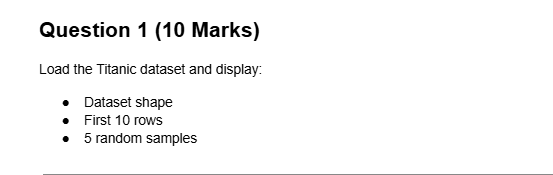

In [31]:

df = pd.read_csv('/content/drive/MyDrive/ML_Data_For_Learning/titanic_data_updated.csv')

df.shape
df.head(10)
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
101,102,no,third,"Petroff, Mr. Pastcho (""Pentcho"")",male,NaN,0,0,349215,7.8958,NaN,S
611,612,no,third,"Jardin, Mr. Jose Neto",male,NaN,0,0,SOTON/O.Q. 3101305,7.0500,NaN,S
551,552,no,second,"Sharp, Mr. Percival James R",male,27.0,0,0,244358,26.0000,NaN,S
94,95,no,third,"Coxon, Mr. Daniel",male,59.0,0,0,364500,7.2500,NaN,S
682,683,no,third,"Olsvigen, Mr. Thor Anderson",male,20.0,0,0,6563,9.2250,NaN,S


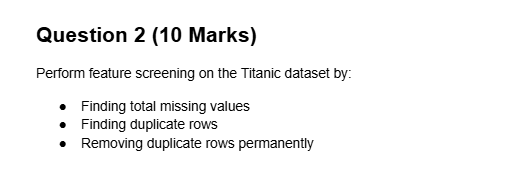

In [5]:
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,False
889,False


In [10]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)


df.duplicated()




,0
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,False
889,False


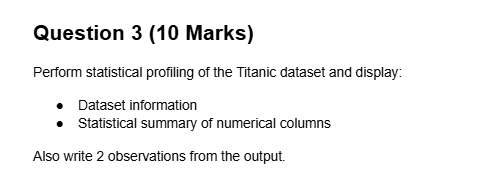

In [11]:
#Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [12]:
#Statistical summary of numerical columns
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


**Observations:**

Average passenger age is around 29 years.

Maximum Fare is much higher than average Fare, indicating presence of outliers.

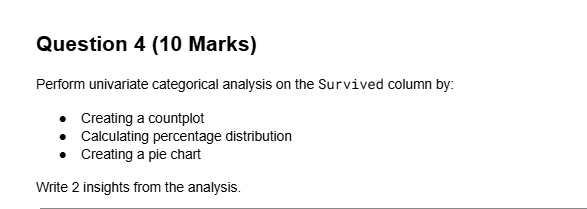

,count
Survived,
no,61.616162
yes,38.383838


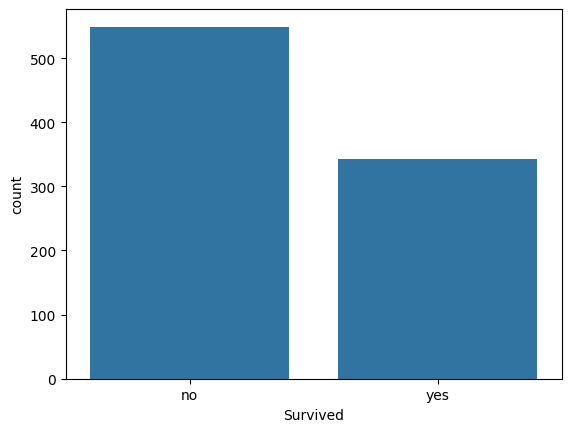

In [16]:
#Creating a countplot
sns.countplot(data= df, x=df['Survived'])

#Calculating percentage distribution
(df['Survived'].value_counts()/len(df))*100



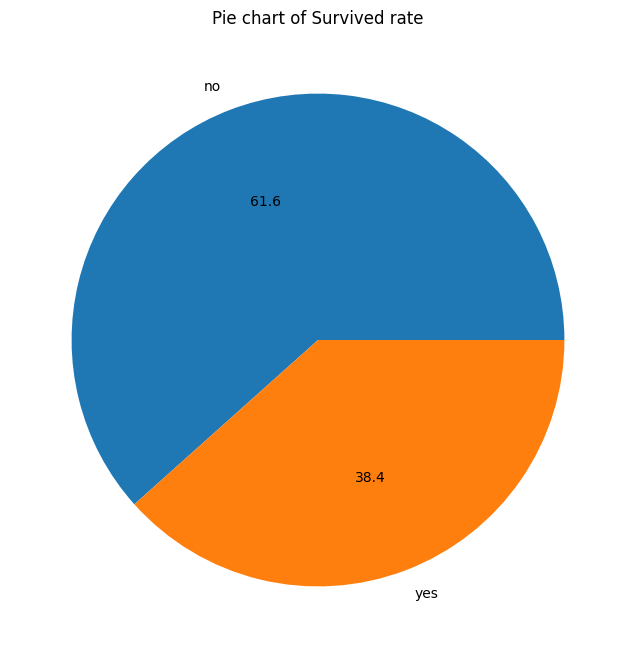

In [17]:
# Pie Chart

Survived_Count = df['Survived'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(Survived_Count,labels=survived_label, autopct="%1.1f" )
plt.title('Pie chart of Survived rate')
plt.show()

**Insights:**

1.Most passengers did not survive the Titanic disaster.

2.Survival percentage is lower than non-survival percentage.

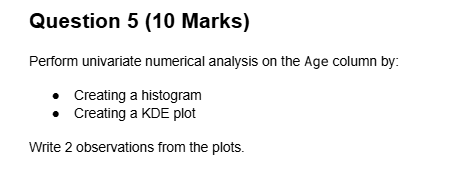

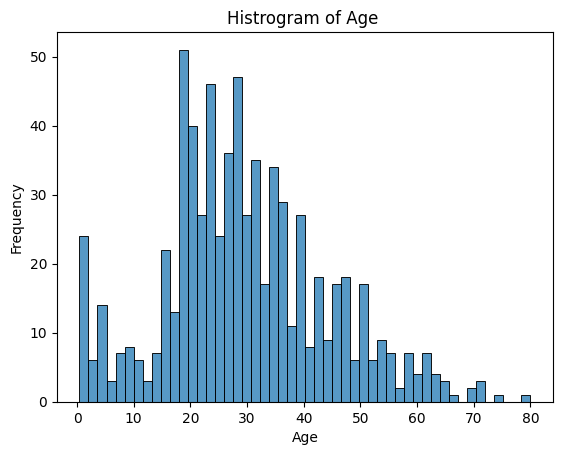

In [20]:
sns.histplot(df['Age'], bins=50)

plt.title('Histrogram of Age ')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

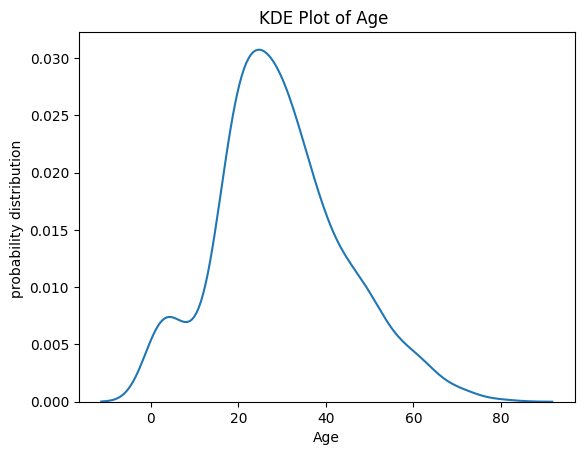

In [21]:
sns.kdeplot(df['Age'])

plt.title('KDE Plot of Age ')
plt.xlabel('Age')
plt.ylabel('probability distribution ')
plt.show()

**Observations:**

Most passengers were between 20–40 years old.

Age distribution is slightly right-skewed.

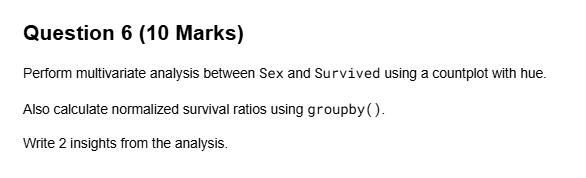

Sex     Survived
female  yes         233
        no           81
male    no          468
        yes         109
Name: count, dtype: int64

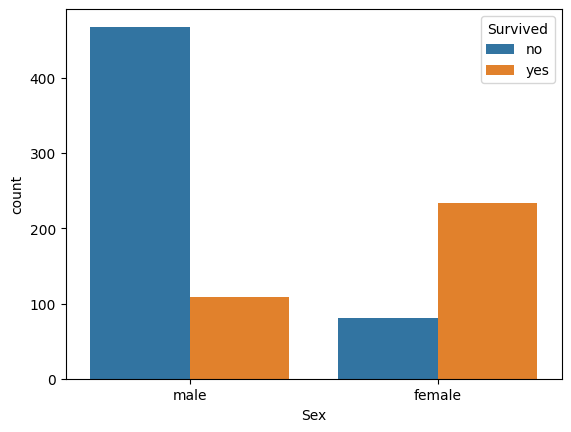

In [24]:
sns.countplot(data= df, x=df['Sex'],hue=df['Survived'])

Survival_Ratio =df.groupby('Sex')['Survived'].value_counts()
Survival_Ratio

Insights:

Female passengers had a higher survival rate than male passengers.

Most male passengers did not survive.

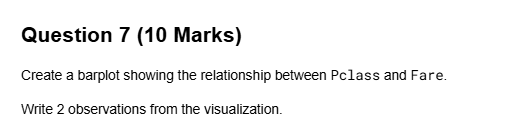

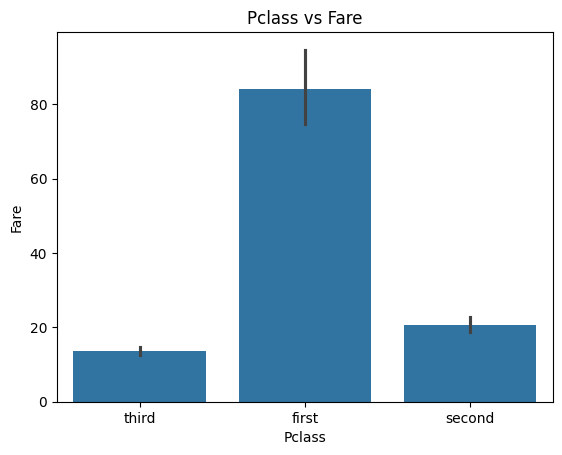

In [26]:
sns.barplot(data=df,x='Pclass',y='Fare')
plt.title("Pclass vs Fare")
plt.show()

## Observations:
First-class passengers paid the highest fare.

Third-class passengers paid the lowest fare.

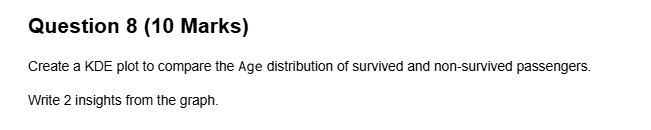

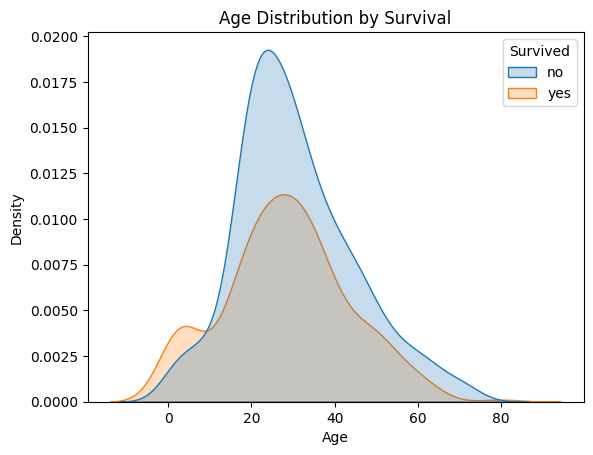

In [27]:
sns.kdeplot(data=df,
            x='Age',
            hue='Survived',
            fill=True)

plt.title("Age Distribution by Survival")
plt.show()

Insights:

Younger passengers had slightly better survival chances.

Non-survived passengers were spread across wider age ranges.

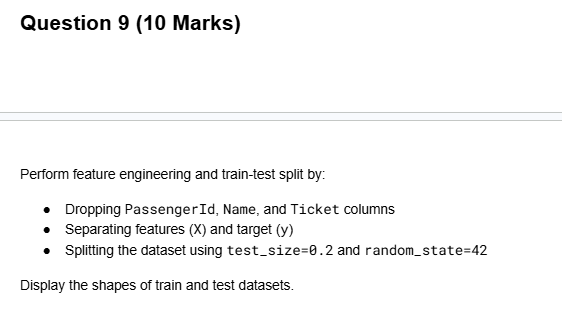

In [32]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# Features and Target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split( X,
                                                     y,
                                                     test_size=0.2,
                                                     random_state=42)

X_train.shape
X_test.shape
y_train.shape
y_test.shape

(179,)

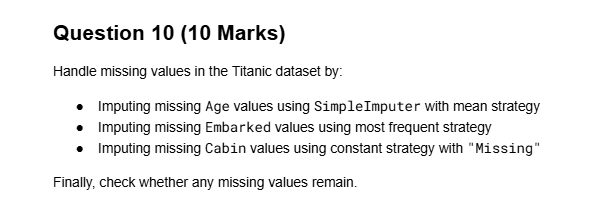

In [44]:
age_imputer = SimpleImputer(strategy='mean')
df[['Age']] = age_imputer.fit_transform(df[['Age']])

#Embarked Imputation
embarked_imputer = SimpleImputer(strategy='most_frequent')
df[['Embarked']] = embarked_imputer.fit_transform(df[['Embarked']])

#Cabin Imputation
cabin_imputer = SimpleImputer( strategy='constant',
                              fill_value='Missing')


df[['Cabin']] = cabin_imputer.fit_transform(df[['Cabin']])



In [46]:
# Final Missing Value Check
df.isnull().sum()


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
